<a href="https://colab.research.google.com/github/tanjiro040/tanjiro040/blob/main/datamining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Overview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

--- Step A: Exploratory Data Analysis (EDA) ---

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64

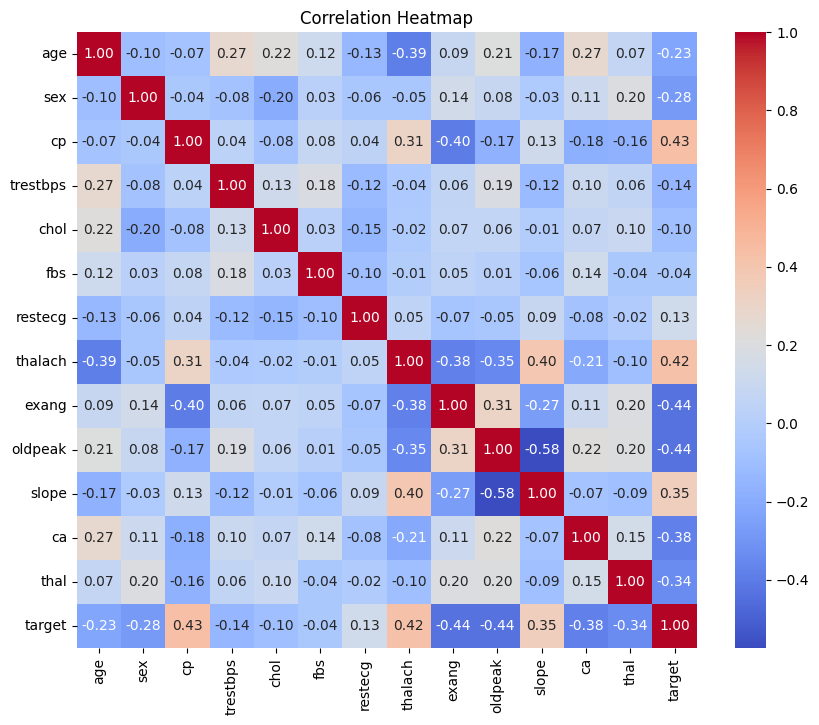

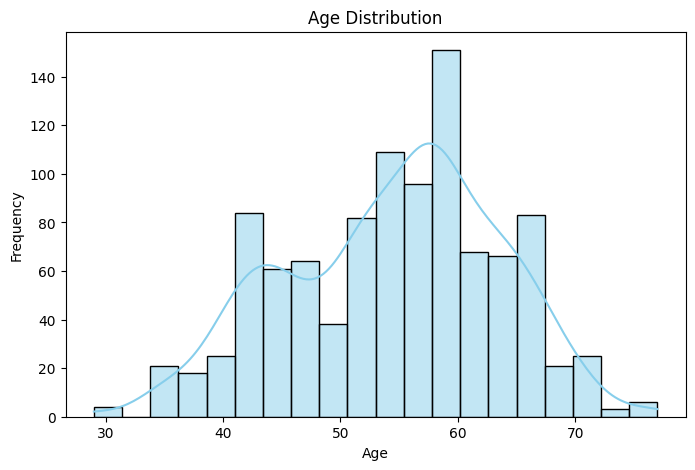

<ipython-input-1-cfbc408016a1>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=data, palette='Set2')


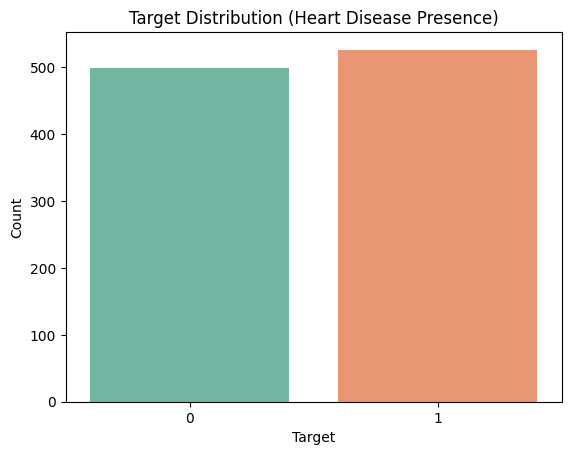


--- Step B: Handling Missing Values ---

Missing Values Before Handling:
age         0
sex         0
cp          0
trestbps    0
chol        6
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing Values After Handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

--- Step C: Discretization ---
Discretized 'age' into age groups:
   age age_group
0   52     50-60
1   53     50-60
2   70     60-70
3   61     60-70
4   62     60-70


<ipython-input-1-cfbc408016a1>:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['chol'].fillna(data['chol'].mean(), inplace=True)
<ipython-input-1-cfbc408016a1>:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_group', data=data, palette='viridis', order=labels)


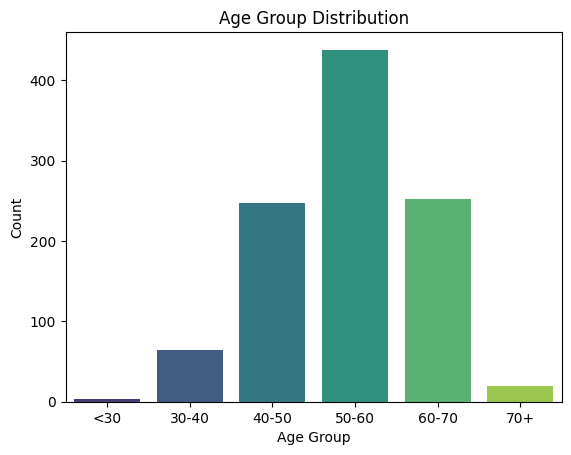

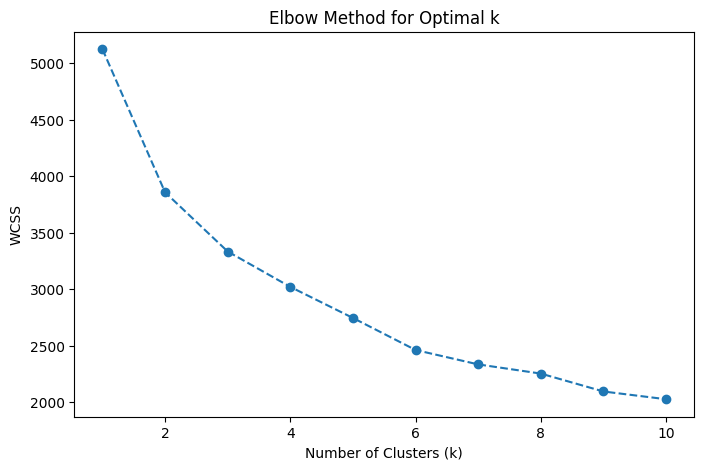

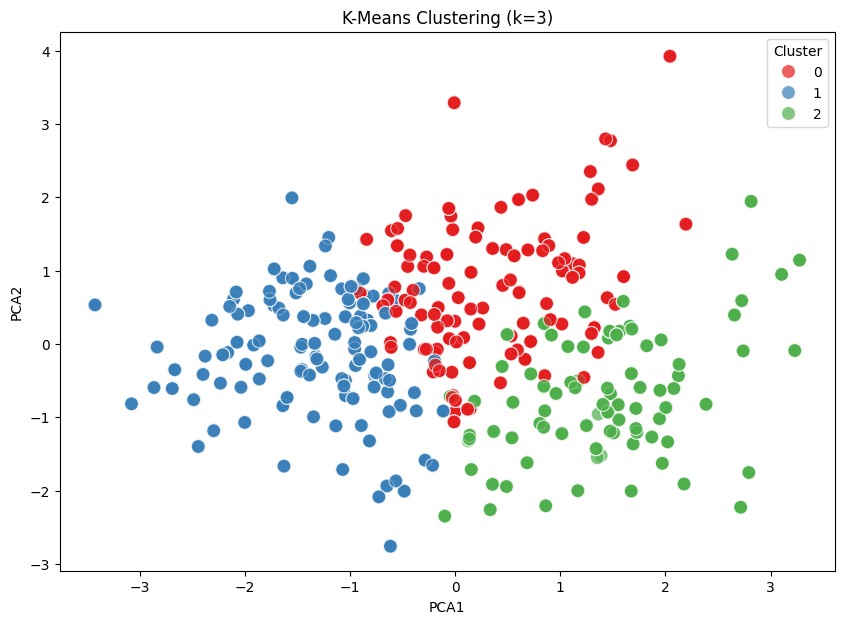


Cluster Analysis:
               age    trestbps        chol     thalach   oldpeak
cluster                                                         
0        60.079545  138.224432  267.366302  152.508523  0.594034
1        45.886076  122.526582  226.635287  162.086076  0.529873
2        59.431655  136.147482  246.232923  126.384892  2.445683


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load a sample chronic disease dataset
url = "/content/heart.csv"  # Example dataset: Heart Disease
data = pd.read_csv(url)

# Display first few rows
print("Dataset Overview:")
print(data.head())

# --- Step A: EDA ---
print("\n--- Step A: Exploratory Data Analysis (EDA) ---")
print("\nDataset Info:")
data.info()  # Overview of the dataset

print("\nSummary Statistics:")
print(data.describe())  # Summary statistics

# Checking for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Visualization: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Visualization: Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['age'], kde=True, bins=20, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Visualization: Target variable distribution
sns.countplot(x='target', data=data, palette='Set2')
plt.title("Target Distribution (Heart Disease Presence)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# --- Step B: Handling Missing Values ---
print("\n--- Step B: Handling Missing Values ---")
# Example: Simulating missing values in a column
data.loc[5:10, 'chol'] = np.nan  # Add missing values to test
print("\nMissing Values Before Handling:")
print(data.isnull().sum())

# Fill missing values in 'chol' (cholesterol) with the mean
data['chol'].fillna(data['chol'].mean(), inplace=True)
print("\nMissing Values After Handling:")
print(data.isnull().sum())

# --- Step C: Discretization ---
print("\n--- Step C: Discretization ---")
# Discretize 'age' into age groups
bins = [0, 30, 40, 50, 60, 70, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60-70', '70+']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels)

print("Discretized 'age' into age groups:")
print(data[['age', 'age_group']].head())

# Visualize the new age groups
sns.countplot(x='age_group', data=data, palette='viridis', order=labels)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()



from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Step 1: Preprocessing ---
# Selecting numerical features for clustering
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
data_clustering = data[numerical_features]

# Standardizing the features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clustering)

# --- Step 2: Applying K-Means Clustering ---
# Determine the optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# From the Elbow Method, select k=3 (example; adjust based on the curve)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
data['cluster'] = kmeans.fit_predict(data_scaled)

# --- Step 3: Visualizing the Clusters ---
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Add PCA components to the dataframe
data['PCA1'] = data_pca[:, 0]
data['PCA2'] = data_pca[:, 1]

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='cluster', data=data, palette='Set1', s=100, alpha=0.7
)
plt.title('K-Means Clustering (k=3)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

# --- Step 4: Analyze Clusters ---
print("\nCluster Analysis:")
print(data.groupby('cluster')[numerical_features].mean())


Dataset Overview:
         date  rainfall  temperature  humidity  wind_speed weather_condition
0  2022-01-01      12.5         15.2      78.0         8.5             Rainy
1  2022-01-02       8.2         17.8      65.0         5.2             Rainy
2  2022-01-03       0.0         20.1      52.0         3.1             Sunny
3  2022-01-04       3.7         18.6      71.0         6.7             Rainy
4  2022-01-05      21.1         14.8      82.0         9.3             Rainy

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4),

<ipython-input-23-76045dd13a5c>:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rainfall_data['rainfall'].fillna(rainfall_data['rainfall'].mean(), inplace=True)


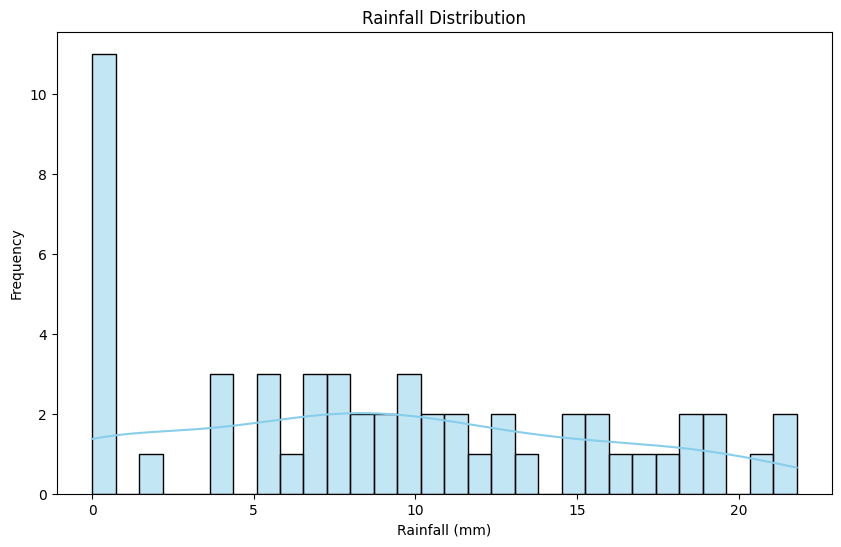

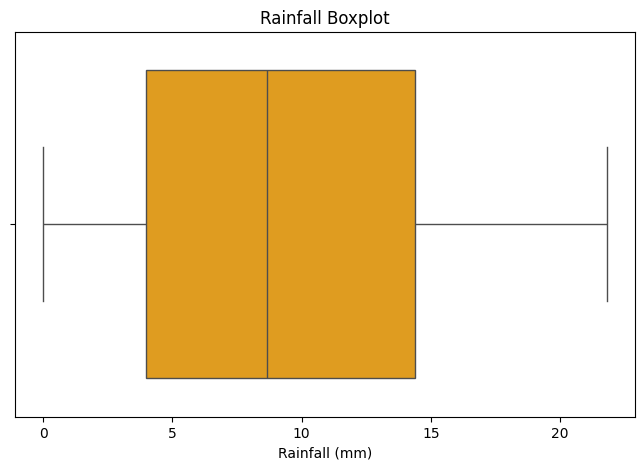


Outliers Before Handling:
Empty DataFrame
Columns: [date, rainfall, temperature, humidity, wind_speed, weather_condition]
Index: []

Outliers After Handling:
Empty DataFrame
Columns: [date, rainfall, temperature, humidity, wind_speed, weather_condition]
Index: []


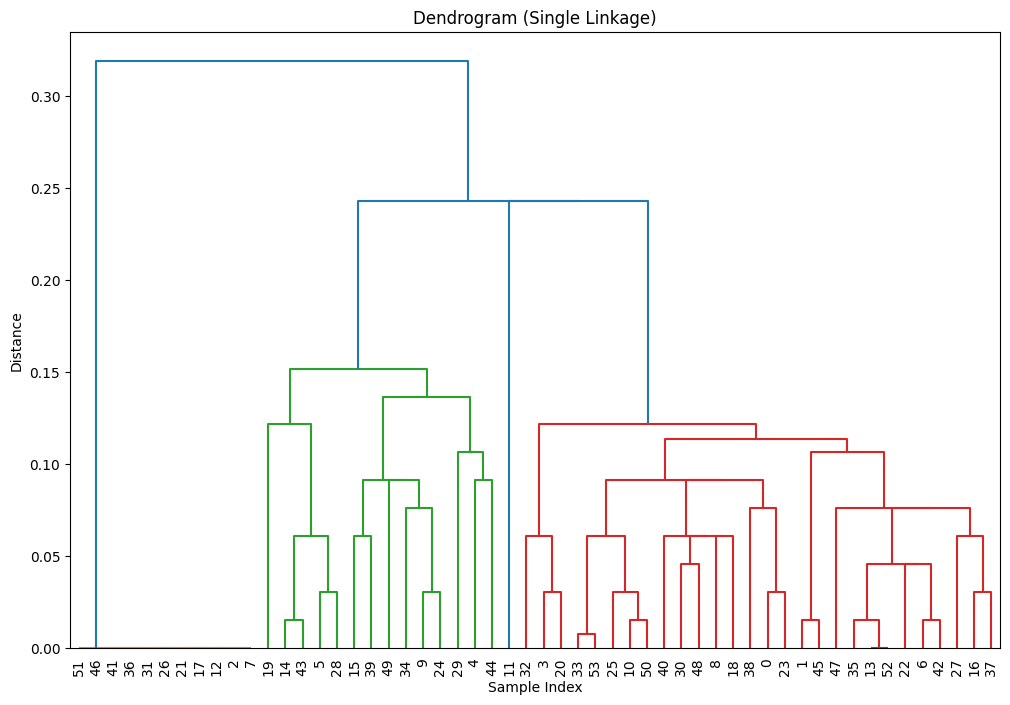

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample Rainfall Dataset
data_url = "/content/rainfall.csv"
rainfall_data = pd.read_csv(data_url)

# Display the first few rows of the dataset
print("Dataset Overview:")
print(rainfall_data.head())

# Basic dataset info
print("\nDataset Info:")
print(rainfall_data.info())

# Summary statistics
print("\nSummary Statistics:")
print(rainfall_data.describe())

# Check for missing values
print("\nMissing Values:")
print(rainfall_data.isnull().sum())
rainfall_data['rainfall'].fillna(rainfall_data['rainfall'].mean(), inplace=True)
print("\nMissing Values After Handling:")
print(data.isnull().sum())

# Visualization: Distribution of Rainfall
plt.figure(figsize=(10, 6))
sns.histplot(rainfall_data['rainfall'], bins=30, kde=True, color="skyblue")
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

# Boxplot of Rainfall
plt.figure(figsize=(8, 5))
sns.boxplot(x=rainfall_data['rainfall'], color="orange")
plt.title("Rainfall Boxplot")
plt.xlabel("Rainfall (mm)")
plt.show()
 # Calculate IQR (Interquartile Range)
Q1 = rainfall_data['rainfall'].quantile(0.25)
Q3 = rainfall_data['rainfall'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect and handle outliers
print("\nOutliers Before Handling:")
outliers = rainfall_data[(rainfall_data['rainfall'] < lower_bound) | (rainfall_data['rainfall'] > upper_bound)]
print(outliers)

# Replace outliers with the median value
median_rainfall = rainfall_data['rainfall'].median()
rainfall_data['rainfall'] = np.where(
    (rainfall_data['rainfall'] < lower_bound) | (rainfall_data['rainfall'] > upper_bound),
    median_rainfall,
    rainfall_data['rainfall']
)
print("\nOutliers After Handling:")
outliers_post = rainfall_data[(rainfall_data['rainfall'] < lower_bound) | (rainfall_data['rainfall'] > upper_bound)]
print(outliers_post)

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Select features for clustering
clustering_features = rainfall_data[['rainfall']].copy()

# Standardize the data
scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

# Perform Single Linkage (MIN) clustering
linkage_matrix = linkage(clustering_features_scaled, method='single')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=rainfall_data.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram (Single Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

Dataset Overview:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summary Statistic

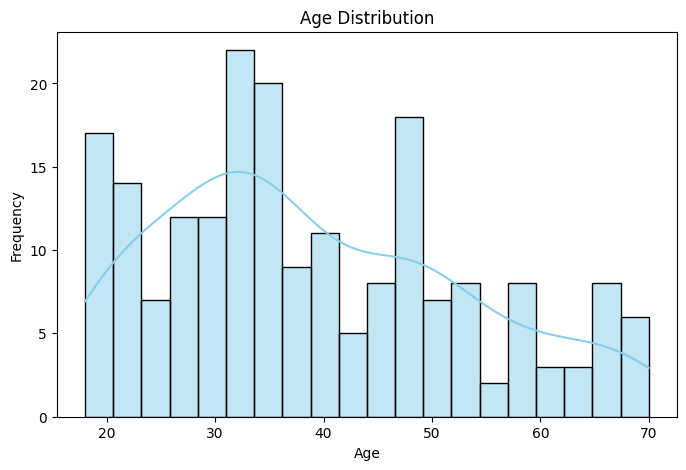

<ipython-input-29-33bca7a800e2>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genre', data=mall_data, palette='Set2')


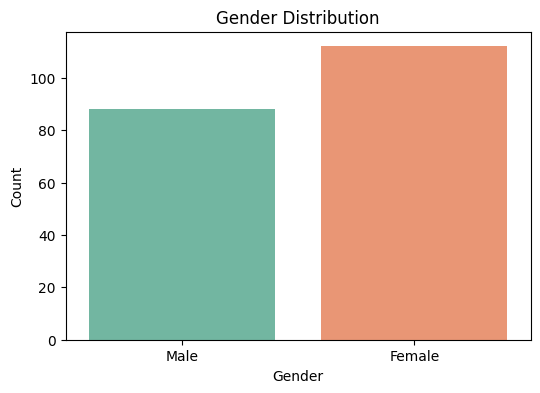

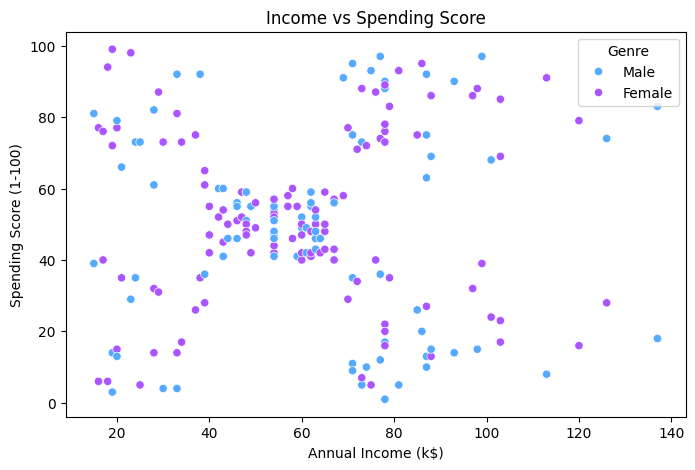

<ipython-input-29-33bca7a800e2>:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mall_data['Age'].fillna(mall_data['Age'].mean(), inplace=True)



Dataset After Handling Missing/Inconsistent Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Standardized Data:
   CustomerID   Genre       Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male -1.460797           -1.738999               -0.434801
1           2    Male -1.313311           -1.738999                1.195704
2           3  Female -1.387054           -1.700830               -1.715913
3           4  Female -1.165825           -1.700830                1.040418
4           5  Female -0.575880           -1.662660               -0.395980


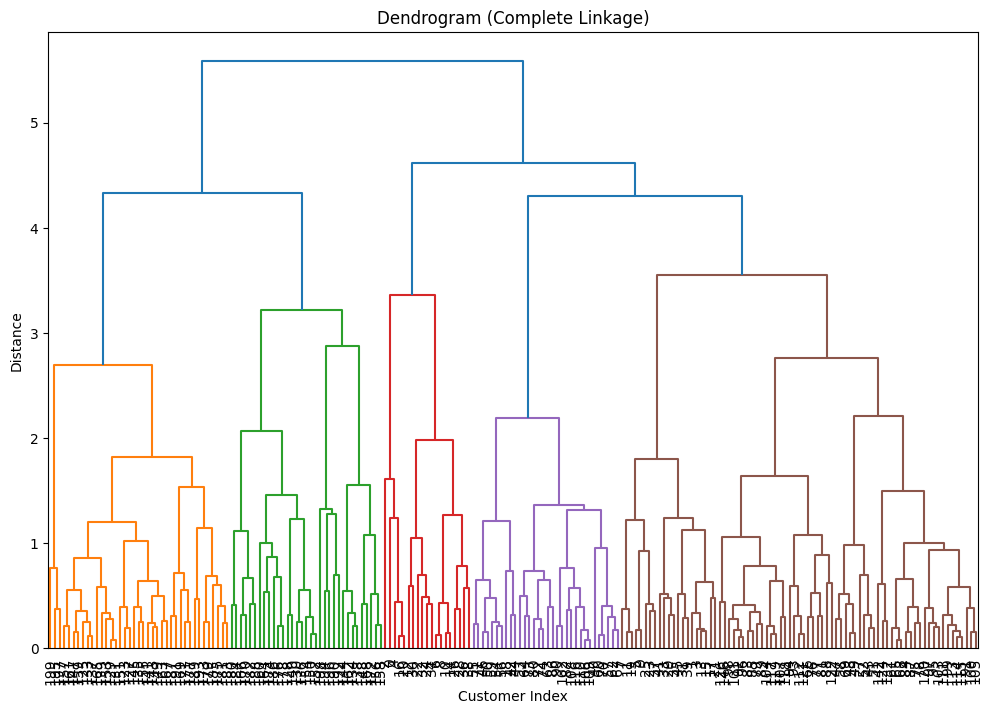

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the Mall_Customers dataset
url = "/content/Mall_Customers.csv"
mall_data = pd.read_csv(url)

# Display first few rows
print("Dataset Overview:")
print(mall_data.head())
 # Basic information about the dataset
print("\nDataset Info:")
print(mall_data.info())

# Summary statistics
print("\nSummary Statistics:")
print(mall_data.describe())

# Checking for missing values
print("\nMissing Values:")
print(mall_data.isnull().sum())

# Visualization: Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(mall_data['Age'], kde=True, bins=20, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Visualization: Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Genre', data=mall_data, palette='Set2')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Scatterplot of Income vs. Spending Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=mall_data, hue='Genre', palette='cool')
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()
 # Simulate missing values for testing
mall_data.loc[5:10, 'Age'] = np.nan

# Handling Missing Values: Fill missing 'Age' with the mean
mall_data['Age'].fillna(mall_data['Age'].mean(), inplace=True)

# Handling inconsistent values: Ensure 'Gender' contains only 'Male' and 'Female'
mall_data['Genre'] = mall_data['Genre'].str.strip()
mall_data = mall_data[mall_data['Genre'].isin(['Male', 'Female'])]

# Verify
print("\nDataset After Handling Missing/Inconsistent Values:")
print(mall_data.isnull().sum())
 # Selecting numerical columns for standardization
numerical_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Standardize the numerical columns
scaler = StandardScaler()
mall_data_scaled = mall_data.copy()
mall_data_scaled[numerical_columns] = scaler.fit_transform(mall_data[numerical_columns])

print("\nStandardized Data:")
print(mall_data_scaled.head())
 # Perform hierarchical clustering using Complete Linkage
features_for_clustering = mall_data_scaled[numerical_columns]
linkage_matrix = linkage(features_for_clustering, method='complete')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=mall_data.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram (Complete Linkage)")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()


Dataset Overview:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8      

<ipython-input-34-98e86bfae440>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=wine_data, palette='viridis')


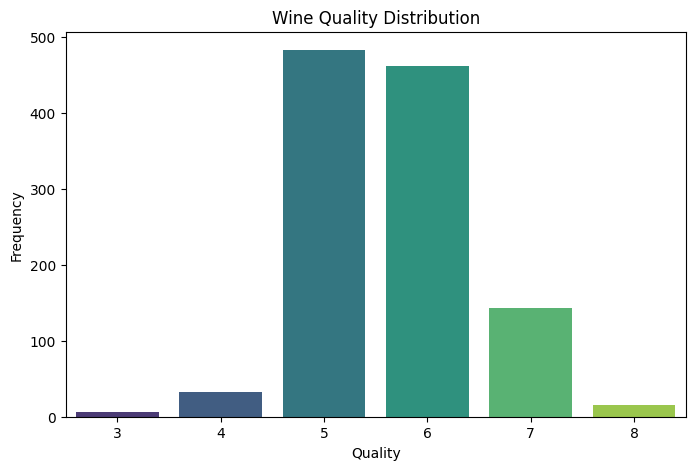

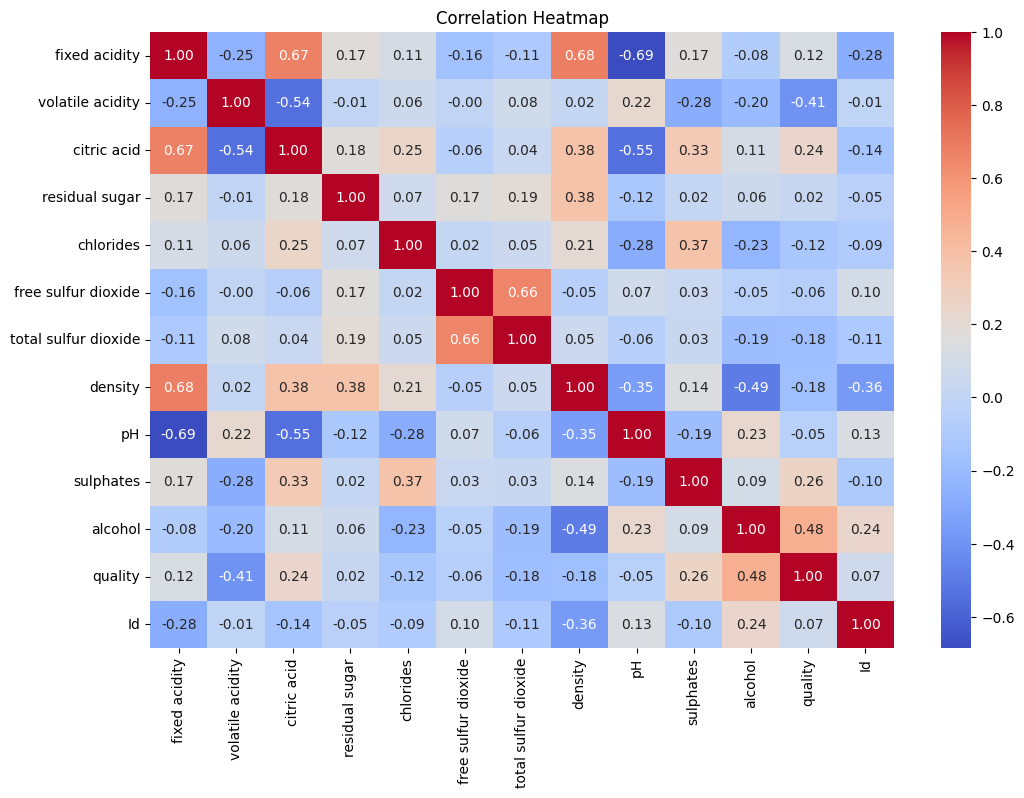

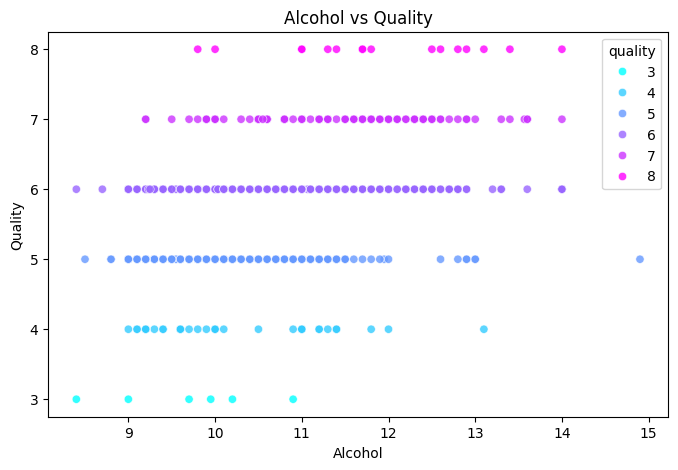


Normalized Data (first 5 rows):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.247788          0.397260         0.00        0.068493   0.106845   
1       0.283186          0.520548         0.00        0.116438   0.143573   
2       0.283186          0.438356         0.04        0.095890   0.133556   
3       0.584071          0.109589         0.56        0.068493   0.105175   
4       0.247788          0.397260         0.00        0.068493   0.106845   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.149254              0.098940  0.567548  0.606299   0.137725   
1             0.358209              0.215548  0.494126  0.362205   0.209581   
2             0.208955              0.169611  0.508811  0.409449   0.191617   
3             0.238806              0.190813  0.582232  0.330709   0.149701   
4             0.149254              0.098940  0.567548  0.606299   0.137725   

    alcohol  quality  I

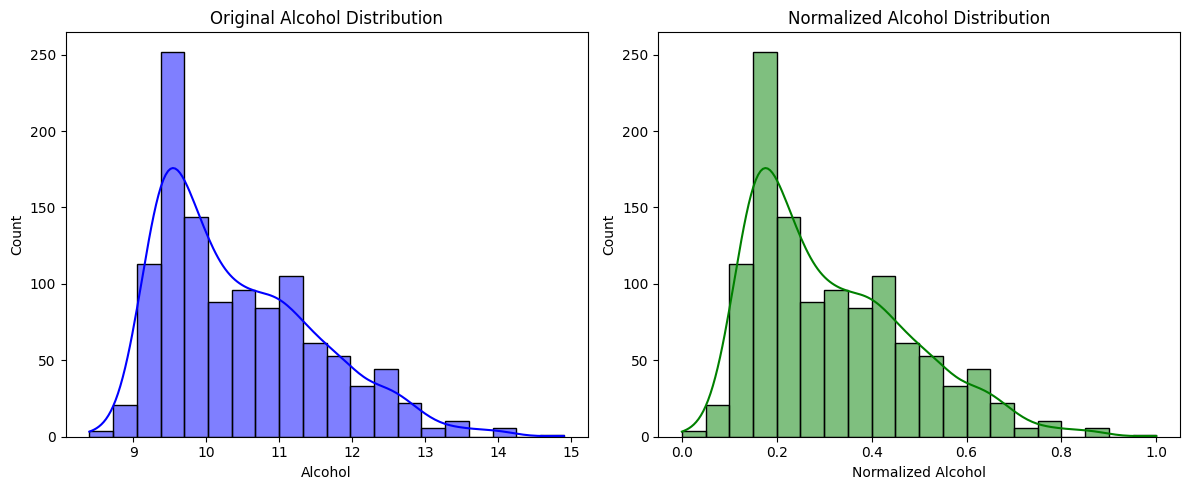

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Load Wine Quality dataset (Red Wine Quality from UCI repository)
url = "/content/WineQT.csv"
wine_data = pd.read_csv(url)

# Display first few rows
print("Dataset Overview:")
print(wine_data.head())
 # Basic information about the dataset
print("\nDataset Info:")
print(wine_data.info())

# Summary statistics
print("\nSummary Statistics:")
print(wine_data.describe())

# Checking for missing values
print("\nMissing Values:")
print(wine_data.isnull().sum())

# Distribution of wine quality
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=wine_data, palette='viridis')
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(wine_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Scatterplot of Alcohol vs Quality
plt.figure(figsize=(8, 5))
sns.scatterplot(x='alcohol', y='quality', data=wine_data, hue='quality', palette='cool', alpha=0.8)
plt.title("Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()
 # Selecting numerical features for normalization
features = wine_data.columns[:-1]  # Exclude 'quality' as it's a target variable

# Applying Min-Max Normalization
scaler = MinMaxScaler()
wine_data_normalized = wine_data.copy()
wine_data_normalized[features] = scaler.fit_transform(wine_data[features])

# Display the normalized data
print("\nNormalized Data (first 5 rows):")
print(wine_data_normalized.head())

# Compare before and after normalization for one feature
plt.figure(figsize=(12, 5))

# Original Data Distribution
plt.subplot(1, 2, 1)
sns.histplot(wine_data['alcohol'], kde=True, bins=20, color='blue')
plt.title("Original Alcohol Distribution")
plt.xlabel("Alcohol")

# Normalized Data Distribution
plt.subplot(1, 2, 2)
sns.histplot(wine_data_normalized['alcohol'], kde=True, bins=20, color='green')
plt.title("Normalized Alcohol Distribution")
plt.xlabel("Normalized Alcohol")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate a dataset with k-NN
def evaluate_knn(dataset, test_size=0.2, k=3):
    # Load data
    X, y = dataset.data, dataset.target

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Create and train the k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Make predictions
    y_pred = knn.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    return accuracy, precision, recall, f1

# Evaluate the Iris dataset
iris_dataset = load_iris()
iris_metrics = evaluate_knn(iris_dataset)

# Evaluate the Wine dataset
wine_dataset = load_wine()
wine_metrics = evaluate_knn(wine_dataset)

# Print results
print("Iris Dataset:")
print(f"Accuracy: {iris_metrics[0]:.2f}, Precision: {iris_metrics[1]:.2f}, Recall: {iris_metrics[2]:.2f}, F1-Score: {iris_metrics[3]:.2f}")

print("\nWine Dataset:")
print(f"Accuracy: {wine_metrics[0]:.2f}, Precision: {wine_metrics[1]:.2f}, Recall: {wine_metrics[2]:.2f}, F1-Score: {wine_metrics[3]:.2f}")

Iris Dataset:
Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1-Score: 1.00

Wine Dataset:
Accuracy: 0.81, Precision: 0.82, Recall: 0.81, F1-Score: 0.81
